In [1]:
import h5py
import halotools
import os
import copy
import warnings
import numpy as np
import math
from astropy.modeling import Fittable1DModel, Parameter,models,fitting
import pickle
import warnings
import numpy.ma as ma
import pandas as pd
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.stats import spearmanr,kendalltau,pearsonr
import palettable
import deepdish as dd
import matplotlib.cm as cm

from matplotlib.collections import LineCollection
from photutils.isophote import EllipseGeometry
from photutils.aperture import EllipticalAperture,EllipticalAnnulus
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
from matplotlib import colors
from astroML.stats import binned_statistic_2d
from scipy.ndimage.filters import gaussian_filter

from astropy.utils.console import ProgressBar
from astropy.table import QTable,hstack
plt.rc('text', usetex=True)
rcParams.update({'axes.linewidth': 1.5})
rcParams.update({'xtick.direction': 'in'})
rcParams.update({'ytick.direction': 'in'})
rcParams.update({'xtick.minor.visible': 'True'})
rcParams.update({'ytick.minor.visible': 'True'})
rcParams.update({'xtick.major.pad': '7.0'})
rcParams.update({'xtick.major.size': '8.0'})
rcParams.update({'xtick.major.width': '1.5'})
rcParams.update({'xtick.minor.pad': '7.0'})
rcParams.update({'xtick.minor.size': '4.0'})
rcParams.update({'xtick.minor.width': '1.5'})
rcParams.update({'ytick.major.pad': '7.0'})
rcParams.update({'ytick.major.size': '8.0'})
rcParams.update({'ytick.major.width': '1.5'})
rcParams.update({'ytick.minor.pad': '7.0'})
rcParams.update({'ytick.minor.size': '4.0'})
rcParams.update({'ytick.minor.width': '1.5'})
rcParams.update({'axes.titlepad': '10.0'})
rcParams.update({'font.size': 35})

/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_55191/4162663930.py:29: DeprecationWarning: Please use `gaussian_filter` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  from scipy.ndimage.filters import gaussian_filter


In [2]:
fig_dir="/Users/xushuo/work/Papers/CenvsSat/Figure/"
data_dir='/Users/xushuo/work/Submit/CenvsSat/Data/'

In [3]:
with open(data_dir+"galaxies_tng300_072_hmc_13_aperture_mass.txt",'rb') as f: 
    tab=pickle.load(f)
mask=(tab['proj']=='xy')
tab1=tab[mask]

In [4]:
with open(data_dir+"galaxies_tng300_072_hmc_13_richness_satellite_mass.txt",'rb') as f: 
    tab_rich0=pickle.load(f)

In [5]:
with open(data_dir+"galaxies_tng300_072_hmc_13_cylinder_richness_satellite_mass.txt",'rb') as f: 
    tab_rich=pickle.load(f)

In [6]:
tab2=hstack([tab[mask],tab_rich0[tab_rich0.colnames[2:]],tab_rich[tab_rich.colnames[2:]]])

In [7]:
df = pd.read_csv(data_dir+'tng_snap.csv')
age_tab=np.asarray(df['age'])
z_tab=np.asarray(df['redshift'])

In [8]:
with open(data_dir+'galaxies_tng300_072_hmc_lensing_prof.txt','rb') as f:
    lensing_cat=pickle.load(f)

In [9]:
with open(data_dir+'galaxies_tng300_072_hmc_lensing_prof_dmo.txt','rb') as f:
    lensing_cat_dmo=pickle.load(f)

In [10]:
cmap1=palettable.lightbartlein.diverging.BlueDarkRed18_10.mpl_colormap

In [11]:
def topNselect(data,name,number):
    data_meta=data.group_by(name)
    data0=data_meta[-number::]
    return data0
def topNoutselect(data,name1,name2,number):
    data_meta=data.group_by(np.log10(data[name1]-data[name2]))
    data0=data_meta[-number::]
    return data0
def linear1d(x,a,b):
    return a*x+b
def mpeakfind(tab,bin_num=30):
    numb,bins=np.histogram(tab,bins=bin_num)
    max_value=max(numb)
    max_index=list(numb).index(max_value)
    mpeak=bins[max_index]
    return mpeak
def resample_list(tab):
    length=len(tab)
    list0=np.random.randint(length,size=length)
    return tab[list0]
def bootstrap_lensing(gal_num_list,rp_bins,times=5000):
    lens_list=[]
    for ii in range(times):
        gal_rand=resample_list(gal_num_list)
        lens_tab=[]
        for i in gal_rand:
            lens_tab.append(lensing_cat[i])
        lens=np.mean(lens_tab,axis=0)
        lens_list.append(lens)
    upper=[]
    lower=[]
    for j in range(len(rp_bins)-1):
        upper.append(np.percentile(np.asarray(lens_list).T[j],84))
        lower.append(np.percentile(np.asarray(lens_list).T[j],16))
    return np.asarray(upper),np.asarray(lower)

In [12]:
logrp_bins = np.linspace(-1,1.5,20)
rp_bins = 10**logrp_bins
logrp_mids = 0.5*(logrp_bins[:-1] + logrp_bins[1:])

In [13]:
mask1=(tab2['c_200c']<15)

In [14]:
def bootstrap_lensing_dmo(gal_num_list,rp_bins,times=5000):
    lens_list=[]
    for ii in range(times):
        gal_rand=resample_list(gal_num_list)
        lens_tab=[]
        for i in gal_rand:
            lens_tab.append(lensing_cat_dmo[i])
        lens=np.mean(lens_tab,axis=0)
        lens_list.append(lens)
    upper=[]
    lower=[]
    for j in range(len(rp_bins)-1):
        upper.append(np.percentile(np.asarray(lens_list).T[j],84))
        lower.append(np.percentile(np.asarray(lens_list).T[j],16))
    return np.asarray(upper),np.asarray(lower)

In [15]:
def bootstrap_ratio_lensing(gal_num_upp,gal_num_down,rp_bins,times=5000):
    ratio_list=[]
    for ii in range(times):
        gal_rand_upp=resample_list(gal_num_upp)
        lens_tab=[]
        for i in gal_rand_upp:
            lens_tab.append(lensing_cat[i])
        lens_upp=np.mean(lens_tab,axis=0)
        gal_rand_down=resample_list(gal_num_down)
        lens_tab=[]
        for i in gal_rand_down:
            lens_tab.append(lensing_cat[i])
        lens_down=np.mean(lens_tab,axis=0)
        ratio_list.append(lens_down/lens_upp)
    upper=[]
    lower=[]
    for j in range(len(rp_bins)-1):
        upper.append(np.percentile(np.asarray(ratio_list).T[j],84))
        lower.append(np.percentile(np.asarray(ratio_list).T[j],16))
    return np.asarray(upper),np.asarray(lower)

In [16]:
def bootstrap_ratio_lensing_dmo(gal_num_upp,gal_num_down,rp_bins,times=5000):
    ratio_list=[]
    for ii in range(times):
        gal_rand_upp=resample_list(gal_num_upp)
        lens_tab=[]
        for i in gal_rand_upp:
            lens_tab.append(lensing_cat_dmo[i])
        lens_upp=np.mean(lens_tab,axis=0)
        gal_rand_down=resample_list(gal_num_down)
        lens_tab=[]
        for i in gal_rand_down:
            lens_tab.append(lensing_cat_dmo[i])
        lens_down=np.mean(lens_tab,axis=0)
        ratio_list.append(lens_down/lens_upp)
    upper=[]
    lower=[]
    for j in range(len(rp_bins)-1):
        upper.append(np.percentile(np.asarray(ratio_list).T[j],84))
        lower.append(np.percentile(np.asarray(ratio_list).T[j],16))
    return np.asarray(upper),np.asarray(lower)

In [17]:
def bootstrap_lensing_ratio_baryon(gal_num_list,rp_bins,times=5000):
    ratio_list=[]
    for ii in range(times):
        gal_rand=resample_list(gal_num_list)
        lens_tab=[]
        lens_tab_dmo=[]
        for i in gal_rand:
            lens_tab.append(lensing_cat[i])
            lens_tab_dmo.append(lensing_cat_dmo[i])
        lens=np.mean(lens_tab,axis=0)
        lens_dmo=np.mean(lens_tab_dmo,axis=0)
        ratio_list.append(lens/lens_dmo)
    upper=[]
    lower=[]
    for j in range(len(rp_bins)-1):
        upper.append(np.percentile(np.asarray(ratio_list).T[j],84))
        lower.append(np.percentile(np.asarray(ratio_list).T[j],16))
    return np.asarray(upper),np.asarray(lower)

/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_55191/1017281462.py:7: RuntimeWarning: divide by zero encountered in log10
  xdata=np.log10(tab2[mask1][name])
/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_55191/1017281462.py:42: RuntimeWarning: divide by zero encountered in log10
  ax1.scatter(np.log10(tab2[mask1][(~mask_up)&(~mask_down)][name]),
/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_55191/1017281462.py:45: RuntimeWarning: divide by zero encountered in log10
  ax1.scatter(np.log10(up_data[name]),np.log10(up_data['aper_100_gal']-up_data['aper_50_gal']),c='orangered',alpha=0.5)


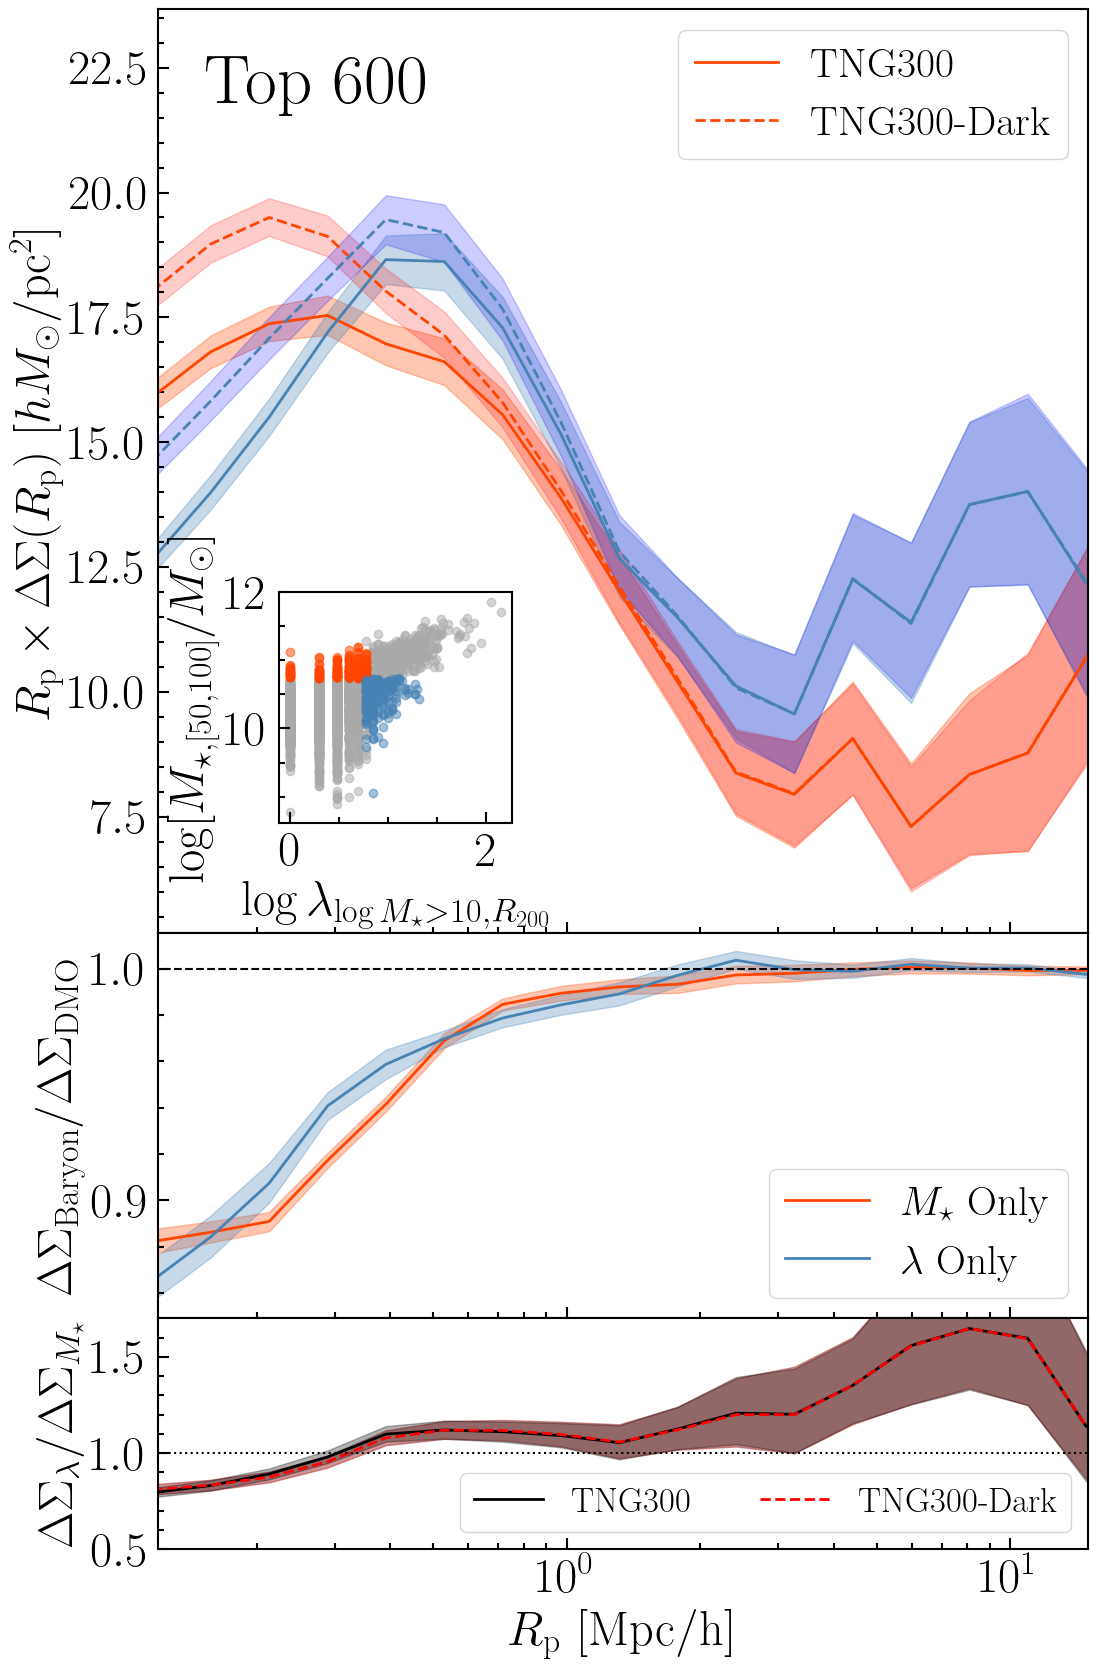

In [22]:
name='richness_cut_r200_10'
label=r'$\log\lambda_{\log M_\star>10,R_{200}}$'
top_numb=600
ydata=np.log10(tab2[mask1]['aper_100_gal']-tab2[mask1]['aper_50_gal'])
topNout=topNoutselect(tab2[mask1],'aper_100_gal','aper_50_gal',top_numb)
mask_l=(ydata>=np.min(np.log10(topNout['aper_100_gal']-topNout['aper_50_gal'])))
xdata=np.log10(tab2[mask1][name])
mask_h1=(xdata>np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
mask_h2=(xdata==np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
index_list=np.where(mask_h2==True)[0]
true_num=top_numb-len(xdata[mask_h1])
array=np.zeros(len(index_list))
array[:true_num]=1
np.random.shuffle(array)
for j in range(len(index_list)):
    index=index_list[j]
    mask_h2[index]=mask_h2[index]&bool(array[j])
mask_h=mask_h1|mask_h2
mask_up=mask_l&(~mask_h)
mask_down=mask_h&(~mask_l)
mask_cro=mask_h&mask_l

up_data=tab2[mask1][mask_up]
down_data=tab2[mask1][mask_down]
up_data_gal_num=up_data['gal_num']
down_data_gal_num=down_data['gal_num']
up_data_lens_tab=[]
for i in up_data_gal_num:
    up_data_lens_tab.append(lensing_cat[i])
up_data_lens=np.mean(up_data_lens_tab,axis=0)
up_upp,up_low=bootstrap_lensing(up_data_gal_num,rp_bins)
down_data_lens_tab=[]
for i in down_data_gal_num:
    down_data_lens_tab.append(lensing_cat[i])
down_data_lens=np.mean(down_data_lens_tab,axis=0)
down_upp,down_low=bootstrap_lensing(down_data_gal_num,rp_bins)

fig=plt.figure(figsize=(12,20))
gs = fig.add_gridspec(3,1, hspace=0, wspace=0.15,height_ratios=(0.6,0.25,0.15))
(ax2,ax3,ax4)=gs.subplots(sharex='col')
ax1 = ax2.inset_axes([0.13, 0.12, 0.25,0.25], transform=ax2.transAxes)
ax1.scatter(np.log10(tab2[mask1][(~mask_up)&(~mask_down)][name]),
            np.log10(tab2[mask1][(~mask_up)&(~mask_down)]['aper_100_gal']-tab2[mask1][(~mask_up)&(~mask_down)]['aper_50_gal']),
            c='darkgrey',alpha=0.5)
ax1.scatter(np.log10(up_data[name]),np.log10(up_data['aper_100_gal']-up_data['aper_50_gal']),c='orangered',alpha=0.5)
ax1.scatter(np.log10(down_data[name]),np.log10(down_data['aper_100_gal']-down_data['aper_50_gal']),c='steelblue',alpha=0.5)

ax1.set_ylabel(r'$\log[M_{\star,[50,100]}/M_\odot]$')
ax1.set_xlabel(label)
ax2.text(0.05,0.9,r'\rm Top %d'%top_numb,transform=ax2.transAxes,fontsize=50)
__=ax2.plot(10**logrp_mids, 10**logrp_mids*up_data_lens/1e12,color='orangered',lw=2,label=r'\rm TNG300')
__=ax2.plot(10**logrp_mids, 10**logrp_mids*down_data_lens/1e12,color='steelblue',lw=2)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*up_upp/1e12,10**logrp_mids*up_low/1e12,color='orangered',alpha=0.3)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*down_upp/1e12,10**logrp_mids*down_low/1e12,color='steelblue',alpha=0.3)

up_data_lens_tab=[]
for i in up_data_gal_num:
    up_data_lens_tab.append(lensing_cat_dmo[i])
up_data_lens_dmo=np.mean(up_data_lens_tab,axis=0)
up_upp,up_low=bootstrap_lensing_dmo(up_data_gal_num,rp_bins)
down_data_lens_tab=[]
for i in down_data_gal_num:
    down_data_lens_tab.append(lensing_cat_dmo[i])
down_data_lens_dmo=np.mean(down_data_lens_tab,axis=0)
down_upp,down_low=bootstrap_lensing_dmo(down_data_gal_num,rp_bins)

__=ax2.plot(10**logrp_mids, 10**logrp_mids*up_data_lens_dmo/1e12,color='orangered',lw=2,ls='--',label=r'\rm TNG300-Dark')
__=ax2.plot(10**logrp_mids, 10**logrp_mids*down_data_lens_dmo/1e12,color='steelblue',lw=2,ls='--')
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*up_upp/1e12,10**logrp_mids*up_low/1e12,color='red',alpha=0.2)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*down_upp/1e12,10**logrp_mids*down_low/1e12,color='blue',alpha=0.2)
ax2.legend(fontsize=30)
ax2.set_xscale('log')
ax2.set_xlim(0.12,15)

up_upp,up_low=bootstrap_lensing_ratio_baryon(up_data_gal_num,rp_bins)
down_upp,down_low=bootstrap_lensing_ratio_baryon(down_data_gal_num,rp_bins)

__=ax3.plot(10**logrp_mids, up_data_lens/up_data_lens_dmo,color='orangered',lw=2,label=r'$M_\star$ {\rm Only}')
__=ax3.plot(10**logrp_mids, down_data_lens/down_data_lens_dmo,color='steelblue',lw=2,label=r'$\lambda$ {\rm Only}')
__=ax3.fill_between(10**logrp_mids, up_upp,up_low,color='orangered',alpha=0.3)
__=ax3.fill_between(10**logrp_mids, down_upp,down_low,color='steelblue',alpha=0.3)
ax3.set_xscale('log')
__=ax3.set_xlabel(r'$R_{\rm p} $  $\rm{[Mpc / h]}$', fontsize=30)
__=ax3.set_ylabel(r'$\Delta\Sigma_{\rm Baryon}/\Delta\Sigma_{\rm DMO}$', fontsize=35)

upper,lower=bootstrap_ratio_lensing(up_data_gal_num,down_data_gal_num,rp_bins)
upper_dmo,lower_dmo=bootstrap_ratio_lensing_dmo(up_data_gal_num,down_data_gal_num,rp_bins)
ax3.legend(fontsize=30)

__=ax4.plot(10**logrp_mids, down_data_lens/up_data_lens,color='black',ls='-',lw=2,label=r'\rm TNG300')
__=ax4.plot(10**logrp_mids, down_data_lens_dmo/up_data_lens_dmo,color='red',ls='--',lw=2,label=r'\rm TNG300-Dark')
__=ax4.fill_between(10**logrp_mids, upper_dmo,lower_dmo,color='brown',alpha=0.5)
__=ax4.fill_between(10**logrp_mids, upper,lower,color='black',alpha=0.3)

ax3.plot(10**logrp_mids,1+0*logrp_mids,ls='--',color='black')
ax4.plot(10**logrp_mids,1+0*logrp_mids,ls='dotted',color='black')
ax4.set_ylabel(r'$\Delta\Sigma_{\lambda}/\Delta\Sigma_{M_\star}$',fontsize=35)
__=ax4.set_xlabel(r'$R_{\rm p} $  $\rm{[Mpc / h]}$', fontsize=35)
__=ax2.set_ylabel(r'$R_{\rm p}\times\Delta\Sigma(R_{\rm p})$  $[h M_{\odot} / {\rm pc}^2]$', fontsize=35)
ax4.set_ylim(0.5,1.7)
ax4.legend(loc=4,fontsize=25,ncol=2)

plt.savefig(fig_dir+"Fig9.pdf",dpi=100)

In [29]:
age_tab[[33,50,59,72]]

array([3.285, 5.878, 7.314, 9.389])

/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_82990/3459245320.py:7: RuntimeWarning: divide by zero encountered in log10
  xdata=np.log10(tab2[mask1][name])
/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_82990/3459245320.py:42: RuntimeWarning: divide by zero encountered in log10
  ax1.scatter(np.log10(tab2[mask1][(~mask_up)&(~mask_down)][name]),
/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_82990/3459245320.py:45: RuntimeWarning: divide by zero encountered in log10
  ax1.scatter(np.log10(up_data[name]),np.log10(up_data['aper_30_gal']),c='orangered',alpha=0.5)


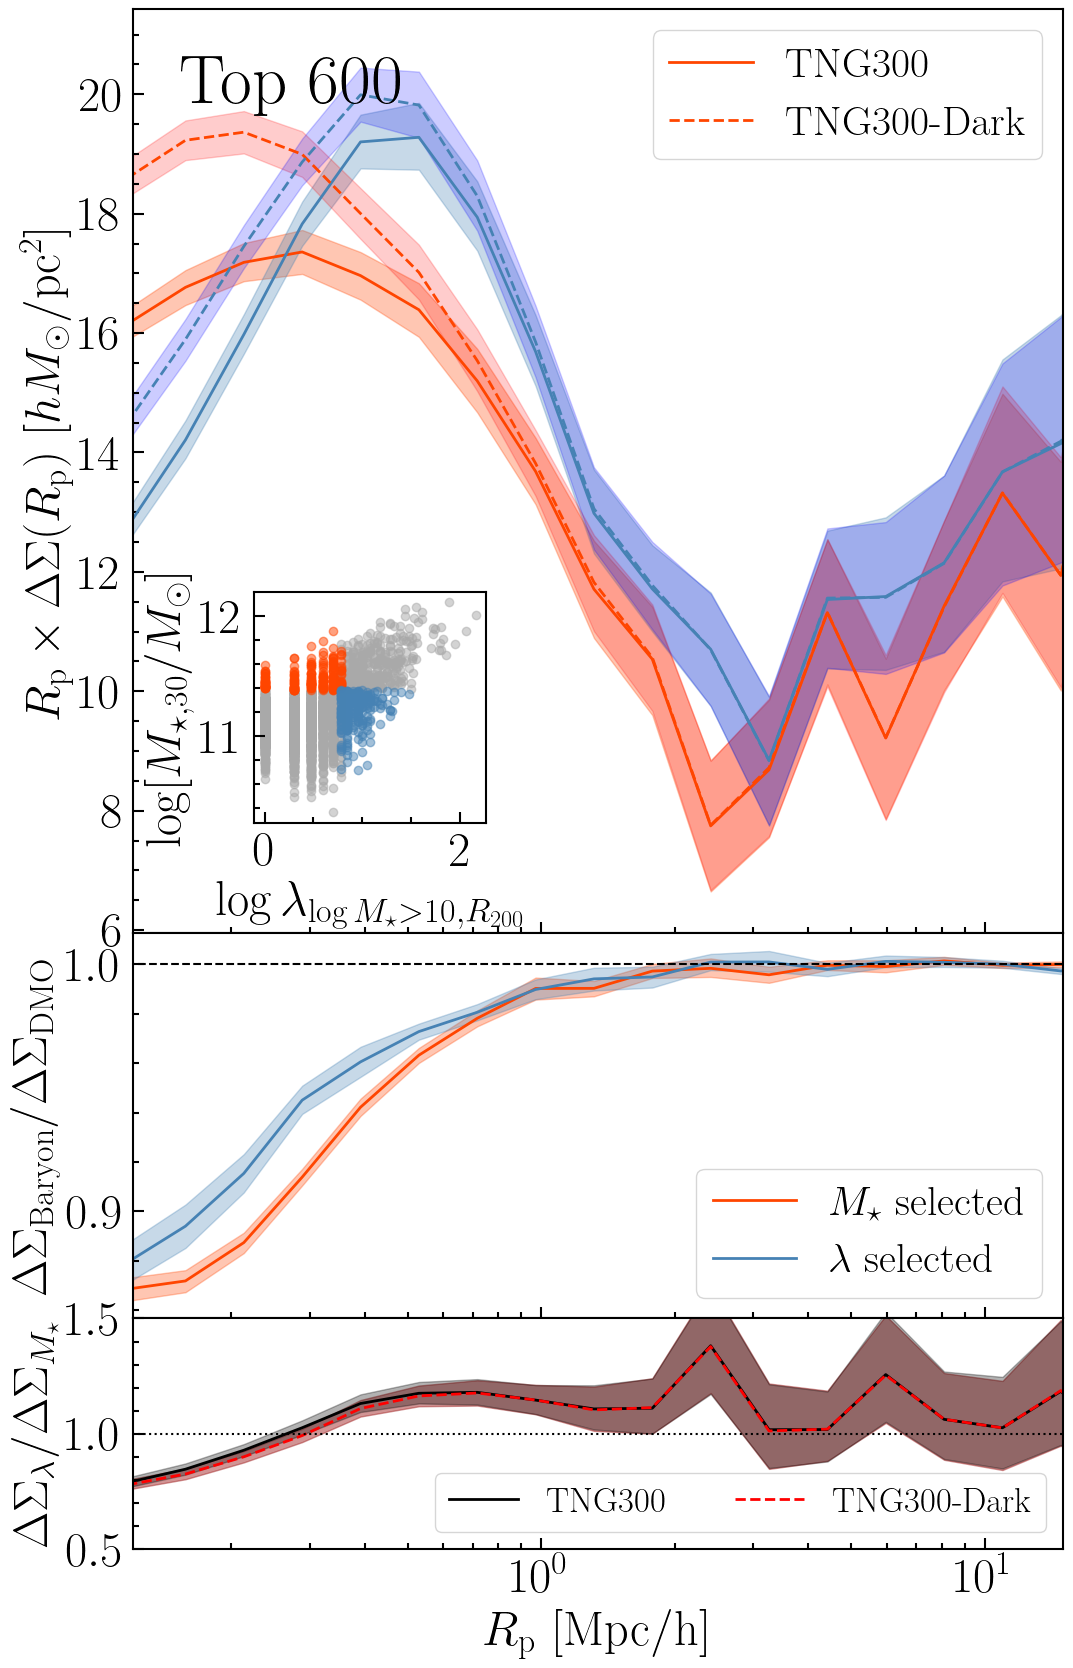

In [20]:
name='richness_cut_r200_10'
label=r'$\log\lambda_{\log M_\star>10,R_{200}}$'
top_numb=600
ydata=np.log10(tab2[mask1]['aper_30_gal'])
topNout=topNselect(tab2[mask1],'aper_30_gal',top_numb)
mask_l=(ydata>=np.min(np.log10(topNout['aper_30_gal'])))
xdata=np.log10(tab2[mask1][name])
mask_h1=(xdata>np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
mask_h2=(xdata==np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
index_list=np.where(mask_h2==True)[0]
true_num=top_numb-len(xdata[mask_h1])
array=np.zeros(len(index_list))
array[:true_num]=1
np.random.shuffle(array)
for j in range(len(index_list)):
    index=index_list[j]
    mask_h2[index]=mask_h2[index]&bool(array[j])
mask_h=mask_h1|mask_h2
mask_up=mask_l&(~mask_h)
mask_down=mask_h&(~mask_l)
mask_cro=mask_h&mask_l

up_data=tab2[mask1][mask_up]
down_data=tab2[mask1][mask_down]
up_data_gal_num=up_data['gal_num']
down_data_gal_num=down_data['gal_num']
up_data_lens_tab=[]
for i in up_data_gal_num:
    up_data_lens_tab.append(lensing_cat[i])
up_data_lens=np.mean(up_data_lens_tab,axis=0)
up_upp,up_low=bootstrap_lensing(up_data_gal_num,rp_bins)
down_data_lens_tab=[]
for i in down_data_gal_num:
    down_data_lens_tab.append(lensing_cat[i])
down_data_lens=np.mean(down_data_lens_tab,axis=0)
down_upp,down_low=bootstrap_lensing(down_data_gal_num,rp_bins)

fig=plt.figure(figsize=(12,20))
gs = fig.add_gridspec(3,1, hspace=0, wspace=0.15,height_ratios=(0.6,0.25,0.15))
(ax2,ax3,ax4)=gs.subplots(sharex='col')
ax1 = ax2.inset_axes([0.13, 0.12, 0.25,0.25], transform=ax2.transAxes)
ax1.scatter(np.log10(tab2[mask1][(~mask_up)&(~mask_down)][name]),
            np.log10(tab2[mask1][(~mask_up)&(~mask_down)]['aper_30_gal']),
            c='darkgrey',alpha=0.5)
ax1.scatter(np.log10(up_data[name]),np.log10(up_data['aper_30_gal']),c='orangered',alpha=0.5)
ax1.scatter(np.log10(down_data[name]),np.log10(down_data['aper_30_gal']),c='steelblue',alpha=0.5)

ax1.set_ylabel(r'$\log[M_{\star,30}/M_\odot]$')
ax1.set_xlabel(label)
ax2.text(0.05,0.9,r'\rm Top %d'%top_numb,transform=ax2.transAxes,fontsize=50)
__=ax2.plot(10**logrp_mids, 10**logrp_mids*up_data_lens/1e12,color='orangered',lw=2,label=r'\rm TNG300')
__=ax2.plot(10**logrp_mids, 10**logrp_mids*down_data_lens/1e12,color='steelblue',lw=2)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*up_upp/1e12,10**logrp_mids*up_low/1e12,color='orangered',alpha=0.3)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*down_upp/1e12,10**logrp_mids*down_low/1e12,color='steelblue',alpha=0.3)

up_data_lens_tab=[]
for i in up_data_gal_num:
    up_data_lens_tab.append(lensing_cat_dmo[i])
up_data_lens_dmo=np.mean(up_data_lens_tab,axis=0)
up_upp,up_low=bootstrap_lensing_dmo(up_data_gal_num,rp_bins)
down_data_lens_tab=[]
for i in down_data_gal_num:
    down_data_lens_tab.append(lensing_cat_dmo[i])
down_data_lens_dmo=np.mean(down_data_lens_tab,axis=0)
down_upp,down_low=bootstrap_lensing_dmo(down_data_gal_num,rp_bins)

__=ax2.plot(10**logrp_mids, 10**logrp_mids*up_data_lens_dmo/1e12,color='orangered',lw=2,ls='--',label=r'\rm TNG300-Dark')
__=ax2.plot(10**logrp_mids, 10**logrp_mids*down_data_lens_dmo/1e12,color='steelblue',lw=2,ls='--')
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*up_upp/1e12,10**logrp_mids*up_low/1e12,color='red',alpha=0.2)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*down_upp/1e12,10**logrp_mids*down_low/1e12,color='blue',alpha=0.2)
ax2.legend(fontsize=30)
ax2.set_xscale('log')
ax2.set_xlim(0.12,15)

up_upp,up_low=bootstrap_lensing_ratio_baryon(up_data_gal_num,rp_bins)
down_upp,down_low=bootstrap_lensing_ratio_baryon(down_data_gal_num,rp_bins)

__=ax3.plot(10**logrp_mids, up_data_lens/up_data_lens_dmo,color='orangered',lw=2,label=r'$M_\star$ {\rm selected}')
__=ax3.plot(10**logrp_mids, down_data_lens/down_data_lens_dmo,color='steelblue',lw=2,label=r'$\lambda$ {\rm selected}')
__=ax3.fill_between(10**logrp_mids, up_upp,up_low,color='orangered',alpha=0.3)
__=ax3.fill_between(10**logrp_mids, down_upp,down_low,color='steelblue',alpha=0.3)
ax3.set_xscale('log')
__=ax3.set_xlabel(r'$R_{\rm p} $  $\rm{[Mpc / h]}$', fontsize=30)
__=ax3.set_ylabel(r'$\Delta\Sigma_{\rm Baryon}/\Delta\Sigma_{\rm DMO}$', fontsize=35)

upper,lower=bootstrap_ratio_lensing(up_data_gal_num,down_data_gal_num,rp_bins)
upper_dmo,lower_dmo=bootstrap_ratio_lensing_dmo(up_data_gal_num,down_data_gal_num,rp_bins)
ax3.legend(fontsize=30)

__=ax4.plot(10**logrp_mids, down_data_lens/up_data_lens,color='black',ls='-',lw=2,label=r'\rm TNG300')
__=ax4.plot(10**logrp_mids, down_data_lens_dmo/up_data_lens_dmo,color='red',ls='--',lw=2,label=r'\rm TNG300-Dark')
__=ax4.fill_between(10**logrp_mids, upper_dmo,lower_dmo,color='brown',alpha=0.5)
__=ax4.fill_between(10**logrp_mids, upper,lower,color='black',alpha=0.3)

ax3.plot(10**logrp_mids,1+0*logrp_mids,ls='--',color='black')
ax4.plot(10**logrp_mids,1+0*logrp_mids,ls='dotted',color='black')
ax4.set_ylabel(r'$\Delta\Sigma_{\lambda}/\Delta\Sigma_{M_\star}$',fontsize=35)
__=ax4.set_xlabel(r'$R_{\rm p} $  $\rm{[Mpc / h]}$', fontsize=35)
__=ax2.set_ylabel(r'$R_{\rm p}\times\Delta\Sigma(R_{\rm p})$  $[h M_{\odot} / {\rm pc}^2]$', fontsize=35)
ax4.set_ylim(0.5,1.5)
ax4.legend(loc=4,fontsize=25,ncol=2)


/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_82990/180319279.py:7: RuntimeWarning: divide by zero encountered in log10
  xdata=np.log10(tab2[mask1][name])
/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_82990/180319279.py:42: RuntimeWarning: divide by zero encountered in log10
  ax1.scatter(np.log10(tab2[mask1][(~mask_up)&(~mask_down)][name]),


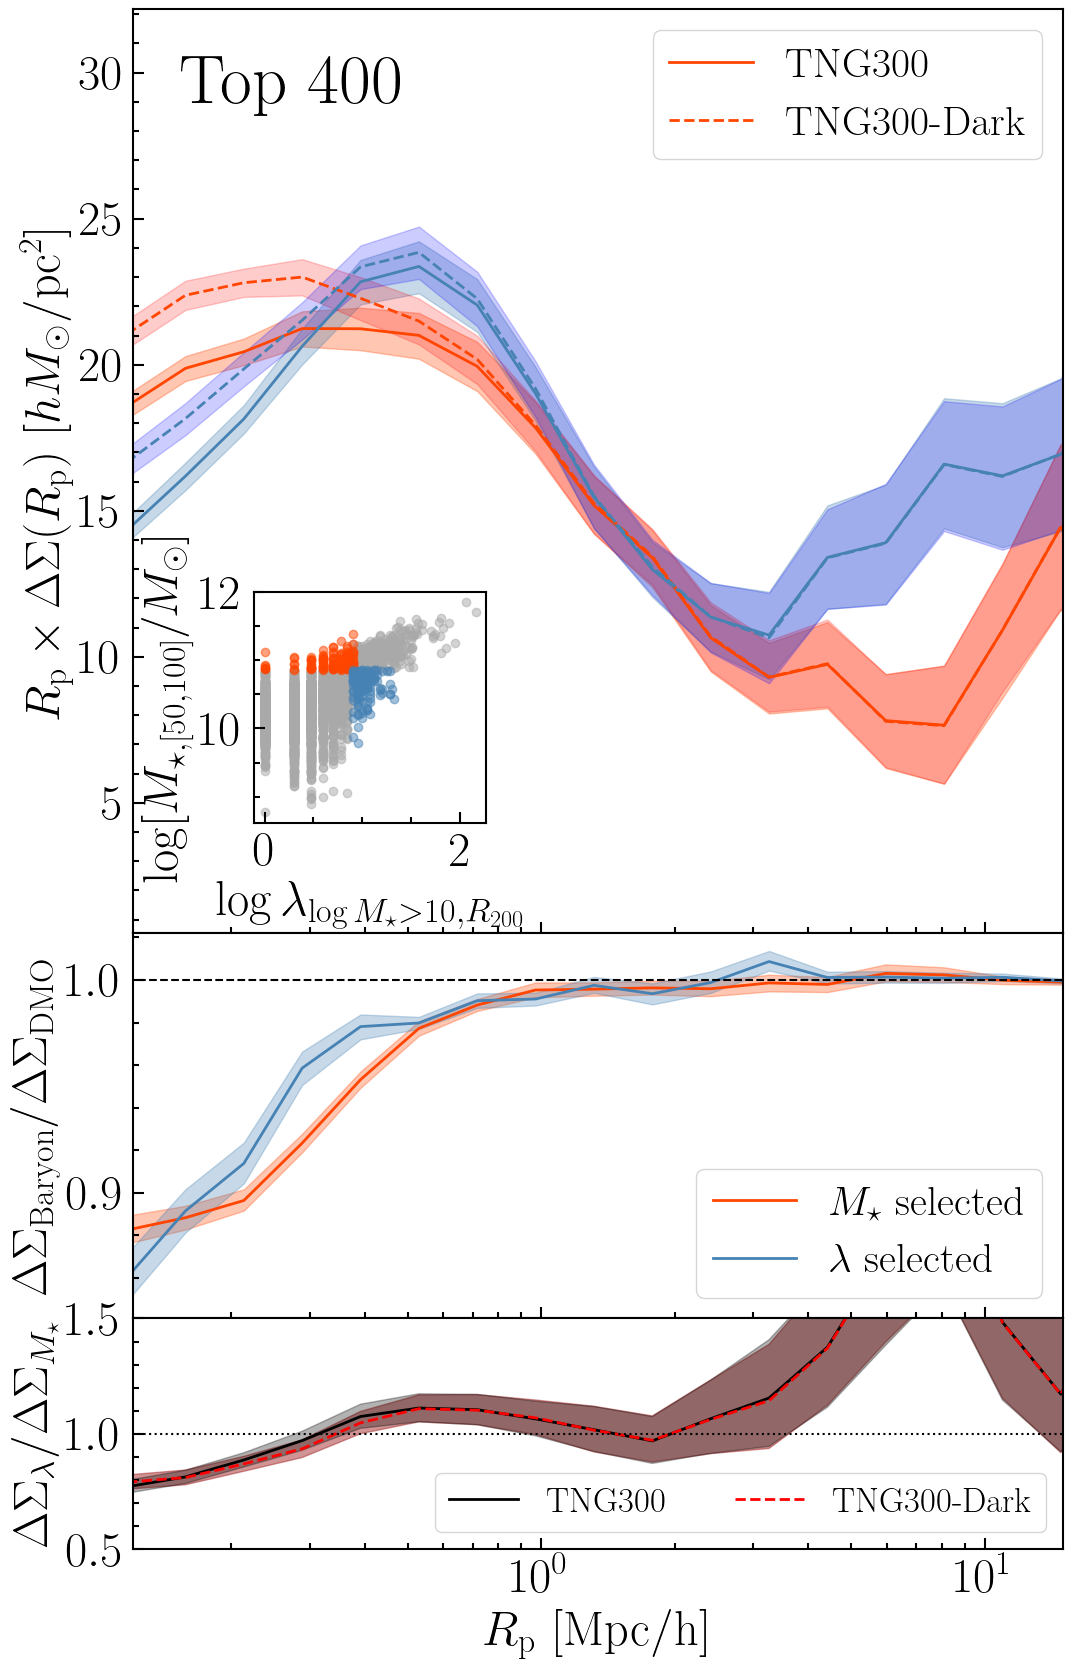

In [21]:
name='richness_cut_r200_10'
label=r'$\log\lambda_{\log M_\star>10,R_{200}}$'
top_numb=400
ydata=np.log10(tab2[mask1]['aper_100_gal']-tab2[mask1]['aper_50_gal'])
topNout=topNoutselect(tab2[mask1],'aper_100_gal','aper_50_gal',top_numb)
mask_l=(ydata>=np.min(np.log10(topNout['aper_100_gal']-topNout['aper_50_gal'])))
xdata=np.log10(tab2[mask1][name])
mask_h1=(xdata>np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
mask_h2=(xdata==np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
index_list=np.where(mask_h2==True)[0]
true_num=top_numb-len(xdata[mask_h1])
array=np.zeros(len(index_list))
array[:true_num]=1
np.random.shuffle(array)
for j in range(len(index_list)):
    index=index_list[j]
    mask_h2[index]=mask_h2[index]&bool(array[j])
mask_h=mask_h1|mask_h2
mask_up=mask_l&(~mask_h)
mask_down=mask_h&(~mask_l)
mask_cro=mask_h&mask_l

up_data=tab2[mask1][mask_up]
down_data=tab2[mask1][mask_down]
up_data_gal_num=up_data['gal_num']
down_data_gal_num=down_data['gal_num']
up_data_lens_tab=[]
for i in up_data_gal_num:
    up_data_lens_tab.append(lensing_cat[i])
up_data_lens=np.mean(up_data_lens_tab,axis=0)
up_upp,up_low=bootstrap_lensing(up_data_gal_num,rp_bins)
down_data_lens_tab=[]
for i in down_data_gal_num:
    down_data_lens_tab.append(lensing_cat[i])
down_data_lens=np.mean(down_data_lens_tab,axis=0)
down_upp,down_low=bootstrap_lensing(down_data_gal_num,rp_bins)

fig=plt.figure(figsize=(12,20))
gs = fig.add_gridspec(3,1, hspace=0, wspace=0.15,height_ratios=(0.6,0.25,0.15))
(ax2,ax3,ax4)=gs.subplots(sharex='col')
ax1 = ax2.inset_axes([0.13, 0.12, 0.25,0.25], transform=ax2.transAxes)
ax1.scatter(np.log10(tab2[mask1][(~mask_up)&(~mask_down)][name]),
            np.log10(tab2[mask1][(~mask_up)&(~mask_down)]['aper_100_gal']-tab2[mask1][(~mask_up)&(~mask_down)]['aper_50_gal']),
            c='darkgrey',alpha=0.5)
ax1.scatter(np.log10(up_data[name]),np.log10(up_data['aper_100_gal']-up_data['aper_50_gal']),c='orangered',alpha=0.5)
ax1.scatter(np.log10(down_data[name]),np.log10(down_data['aper_100_gal']-down_data['aper_50_gal']),c='steelblue',alpha=0.5)

ax1.set_ylabel(r'$\log[M_{\star,[50,100]}/M_\odot]$')
ax1.set_xlabel(label)
ax2.text(0.05,0.9,r'\rm Top %d'%top_numb,transform=ax2.transAxes,fontsize=50)
__=ax2.plot(10**logrp_mids, 10**logrp_mids*up_data_lens/1e12,color='orangered',lw=2,label=r'\rm TNG300')
__=ax2.plot(10**logrp_mids, 10**logrp_mids*down_data_lens/1e12,color='steelblue',lw=2)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*up_upp/1e12,10**logrp_mids*up_low/1e12,color='orangered',alpha=0.3)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*down_upp/1e12,10**logrp_mids*down_low/1e12,color='steelblue',alpha=0.3)

up_data_lens_tab=[]
for i in up_data_gal_num:
    up_data_lens_tab.append(lensing_cat_dmo[i])
up_data_lens_dmo=np.mean(up_data_lens_tab,axis=0)
up_upp,up_low=bootstrap_lensing_dmo(up_data_gal_num,rp_bins)
down_data_lens_tab=[]
for i in down_data_gal_num:
    down_data_lens_tab.append(lensing_cat_dmo[i])
down_data_lens_dmo=np.mean(down_data_lens_tab,axis=0)
down_upp,down_low=bootstrap_lensing_dmo(down_data_gal_num,rp_bins)

__=ax2.plot(10**logrp_mids, 10**logrp_mids*up_data_lens_dmo/1e12,color='orangered',lw=2,ls='--',label=r'\rm TNG300-Dark')
__=ax2.plot(10**logrp_mids, 10**logrp_mids*down_data_lens_dmo/1e12,color='steelblue',lw=2,ls='--')
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*up_upp/1e12,10**logrp_mids*up_low/1e12,color='red',alpha=0.2)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*down_upp/1e12,10**logrp_mids*down_low/1e12,color='blue',alpha=0.2)
ax2.legend(fontsize=30)
ax2.set_xscale('log')
ax2.set_xlim(0.12,15)

up_upp,up_low=bootstrap_lensing_ratio_baryon(up_data_gal_num,rp_bins)
down_upp,down_low=bootstrap_lensing_ratio_baryon(down_data_gal_num,rp_bins)

__=ax3.plot(10**logrp_mids, up_data_lens/up_data_lens_dmo,color='orangered',lw=2,label=r'$M_\star$ {\rm selected}')
__=ax3.plot(10**logrp_mids, down_data_lens/down_data_lens_dmo,color='steelblue',lw=2,label=r'$\lambda$ {\rm selected}')
__=ax3.fill_between(10**logrp_mids, up_upp,up_low,color='orangered',alpha=0.3)
__=ax3.fill_between(10**logrp_mids, down_upp,down_low,color='steelblue',alpha=0.3)
ax3.set_xscale('log')
__=ax3.set_xlabel(r'$R_{\rm p} $  $\rm{[Mpc / h]}$', fontsize=30)
__=ax3.set_ylabel(r'$\Delta\Sigma_{\rm Baryon}/\Delta\Sigma_{\rm DMO}$', fontsize=35)

upper,lower=bootstrap_ratio_lensing(up_data_gal_num,down_data_gal_num,rp_bins)
upper_dmo,lower_dmo=bootstrap_ratio_lensing_dmo(up_data_gal_num,down_data_gal_num,rp_bins)
ax3.legend(fontsize=30)

__=ax4.plot(10**logrp_mids, down_data_lens/up_data_lens,color='black',ls='-',lw=2,label=r'\rm TNG300')
__=ax4.plot(10**logrp_mids, down_data_lens_dmo/up_data_lens_dmo,color='red',ls='--',lw=2,label=r'\rm TNG300-Dark')
__=ax4.fill_between(10**logrp_mids, upper_dmo,lower_dmo,color='brown',alpha=0.5)
__=ax4.fill_between(10**logrp_mids, upper,lower,color='black',alpha=0.3)

ax3.plot(10**logrp_mids,1+0*logrp_mids,ls='--',color='black')
ax4.plot(10**logrp_mids,1+0*logrp_mids,ls='dotted',color='black')
ax4.set_ylabel(r'$\Delta\Sigma_{\lambda}/\Delta\Sigma_{M_\star}$',fontsize=35)
__=ax4.set_xlabel(r'$R_{\rm p} $  $\rm{[Mpc / h]}$', fontsize=35)
__=ax2.set_ylabel(r'$R_{\rm p}\times\Delta\Sigma(R_{\rm p})$  $[h M_{\odot} / {\rm pc}^2]$', fontsize=35)
ax4.set_ylim(0.5,1.5)
ax4.legend(loc=4,fontsize=25,ncol=2)

/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_5128/3354940900.py:7: RuntimeWarning: divide by zero encountered in log10
  xdata=np.log10(tab2[mask1][name])
/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_5128/3354940900.py:42: RuntimeWarning: divide by zero encountered in log10
  ax1.scatter(np.log10(tab2[mask1][(~mask_up)&(~mask_down)][name]),
/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_5128/3354940900.py:45: RuntimeWarning: divide by zero encountered in log10
  ax1.scatter(np.log10(up_data[name]),np.log10(up_data['aper_100_gal']-up_data['aper_50_gal']),c='orangered',alpha=0.5)


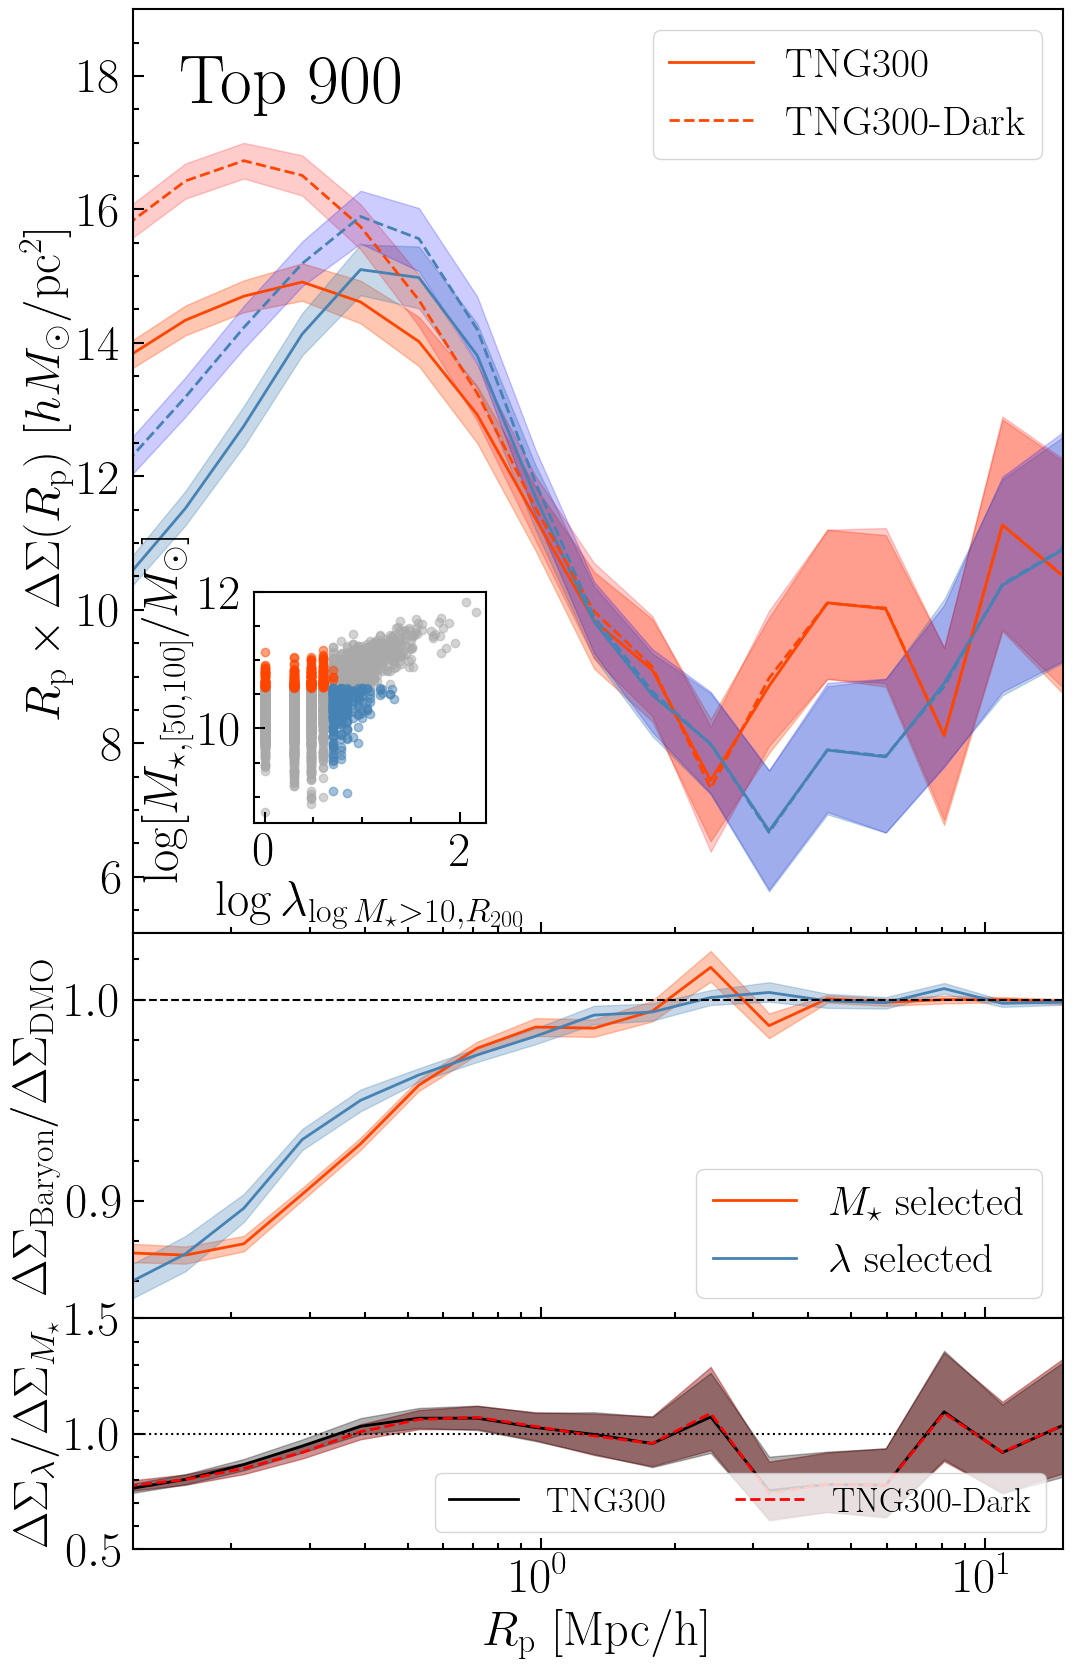

In [20]:
name='richness_cut_r200_10'
label=r'$\log\lambda_{\log M_\star>10,R_{200}}$'
top_numb=900
ydata=np.log10(tab2[mask1]['aper_100_gal']-tab2[mask1]['aper_50_gal'])
topNout=topNoutselect(tab2[mask1],'aper_100_gal','aper_50_gal',top_numb)
mask_l=(ydata>=np.min(np.log10(topNout['aper_100_gal']-topNout['aper_50_gal'])))
xdata=np.log10(tab2[mask1][name])
mask_h1=(xdata>np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
mask_h2=(xdata==np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
index_list=np.where(mask_h2==True)[0]
true_num=top_numb-len(xdata[mask_h1])
array=np.zeros(len(index_list))
array[:true_num]=1
np.random.shuffle(array)
for j in range(len(index_list)):
    index=index_list[j]
    mask_h2[index]=mask_h2[index]&bool(array[j])
mask_h=mask_h1|mask_h2
mask_up=mask_l&(~mask_h)
mask_down=mask_h&(~mask_l)
mask_cro=mask_h&mask_l

up_data=tab2[mask1][mask_up]
down_data=tab2[mask1][mask_down]
up_data_gal_num=up_data['gal_num']
down_data_gal_num=down_data['gal_num']
up_data_lens_tab=[]
for i in up_data_gal_num:
    up_data_lens_tab.append(lensing_cat[i])
up_data_lens=np.mean(up_data_lens_tab,axis=0)
up_upp,up_low=bootstrap_lensing(up_data_gal_num,rp_bins)
down_data_lens_tab=[]
for i in down_data_gal_num:
    down_data_lens_tab.append(lensing_cat[i])
down_data_lens=np.mean(down_data_lens_tab,axis=0)
down_upp,down_low=bootstrap_lensing(down_data_gal_num,rp_bins)

fig=plt.figure(figsize=(12,20))
gs = fig.add_gridspec(3,1, hspace=0, wspace=0.15,height_ratios=(0.6,0.25,0.15))
(ax2,ax3,ax4)=gs.subplots(sharex='col')
ax1 = ax2.inset_axes([0.13, 0.12, 0.25,0.25], transform=ax2.transAxes)
ax1.scatter(np.log10(tab2[mask1][(~mask_up)&(~mask_down)][name]),
            np.log10(tab2[mask1][(~mask_up)&(~mask_down)]['aper_100_gal']-tab2[mask1][(~mask_up)&(~mask_down)]['aper_50_gal']),
            c='darkgrey',alpha=0.5)
ax1.scatter(np.log10(up_data[name]),np.log10(up_data['aper_100_gal']-up_data['aper_50_gal']),c='orangered',alpha=0.5)
ax1.scatter(np.log10(down_data[name]),np.log10(down_data['aper_100_gal']-down_data['aper_50_gal']),c='steelblue',alpha=0.5)

ax1.set_ylabel(r'$\log[M_{\star,[50,100]}/M_\odot]$')
ax1.set_xlabel(label)
ax2.text(0.05,0.9,r'\rm Top %d'%top_numb,transform=ax2.transAxes,fontsize=50)
__=ax2.plot(10**logrp_mids, 10**logrp_mids*up_data_lens/1e12,color='orangered',lw=2,label=r'\rm TNG300')
__=ax2.plot(10**logrp_mids, 10**logrp_mids*down_data_lens/1e12,color='steelblue',lw=2)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*up_upp/1e12,10**logrp_mids*up_low/1e12,color='orangered',alpha=0.3)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*down_upp/1e12,10**logrp_mids*down_low/1e12,color='steelblue',alpha=0.3)

up_data_lens_tab=[]
for i in up_data_gal_num:
    up_data_lens_tab.append(lensing_cat_dmo[i])
up_data_lens_dmo=np.mean(up_data_lens_tab,axis=0)
up_upp,up_low=bootstrap_lensing_dmo(up_data_gal_num,rp_bins)
down_data_lens_tab=[]
for i in down_data_gal_num:
    down_data_lens_tab.append(lensing_cat_dmo[i])
down_data_lens_dmo=np.mean(down_data_lens_tab,axis=0)
down_upp,down_low=bootstrap_lensing_dmo(down_data_gal_num,rp_bins)

__=ax2.plot(10**logrp_mids, 10**logrp_mids*up_data_lens_dmo/1e12,color='orangered',lw=2,ls='--',label=r'\rm TNG300-Dark')
__=ax2.plot(10**logrp_mids, 10**logrp_mids*down_data_lens_dmo/1e12,color='steelblue',lw=2,ls='--')
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*up_upp/1e12,10**logrp_mids*up_low/1e12,color='red',alpha=0.2)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*down_upp/1e12,10**logrp_mids*down_low/1e12,color='blue',alpha=0.2)
ax2.legend(fontsize=30)
ax2.set_xscale('log')
ax2.set_xlim(0.12,15)

up_upp,up_low=bootstrap_lensing_ratio_baryon(up_data_gal_num,rp_bins)
down_upp,down_low=bootstrap_lensing_ratio_baryon(down_data_gal_num,rp_bins)

__=ax3.plot(10**logrp_mids, up_data_lens/up_data_lens_dmo,color='orangered',lw=2,label=r'$M_\star$ {\rm selected}')
__=ax3.plot(10**logrp_mids, down_data_lens/down_data_lens_dmo,color='steelblue',lw=2,label=r'$\lambda$ {\rm selected}')
__=ax3.fill_between(10**logrp_mids, up_upp,up_low,color='orangered',alpha=0.3)
__=ax3.fill_between(10**logrp_mids, down_upp,down_low,color='steelblue',alpha=0.3)
ax3.set_xscale('log')
__=ax3.set_xlabel(r'$R_{\rm p} $  $\rm{[Mpc / h]}$', fontsize=30)
__=ax3.set_ylabel(r'$\Delta\Sigma_{\rm Baryon}/\Delta\Sigma_{\rm DMO}$', fontsize=35)

upper,lower=bootstrap_ratio_lensing(up_data_gal_num,down_data_gal_num,rp_bins)
upper_dmo,lower_dmo=bootstrap_ratio_lensing_dmo(up_data_gal_num,down_data_gal_num,rp_bins)
ax3.legend(fontsize=30)

__=ax4.plot(10**logrp_mids, down_data_lens/up_data_lens,color='black',ls='-',lw=2,label=r'\rm TNG300')
__=ax4.plot(10**logrp_mids, down_data_lens_dmo/up_data_lens_dmo,color='red',ls='--',lw=2,label=r'\rm TNG300-Dark')
__=ax4.fill_between(10**logrp_mids, upper_dmo,lower_dmo,color='brown',alpha=0.5)
__=ax4.fill_between(10**logrp_mids, upper,lower,color='black',alpha=0.3)

ax3.plot(10**logrp_mids,1+0*logrp_mids,ls='--',color='black')
ax4.plot(10**logrp_mids,1+0*logrp_mids,ls='dotted',color='black')
ax4.set_ylabel(r'$\Delta\Sigma_{\lambda}/\Delta\Sigma_{M_\star}$',fontsize=35)
__=ax4.set_xlabel(r'$R_{\rm p} $  $\rm{[Mpc / h]}$', fontsize=35)
__=ax2.set_ylabel(r'$R_{\rm p}\times\Delta\Sigma(R_{\rm p})$  $[h M_{\odot} / {\rm pc}^2]$', fontsize=35)
ax4.set_ylim(0.5,1.5)
ax4.legend(loc=4,fontsize=25,ncol=2)